## Imports

In [1]:
import textwrap
import re
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

## Configuration & styling

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
EMOTION_MAP = {
    "neutralny": "neutral",
    "neutralnywyraztwarzy": "neutral",
    "neutralny_wyraz_twarzy": "neutral",
    "wstret": "disgust",
    "wstręt": "disgust",
    "radosc": "joy",
    "radość": "joy",
    "smutek": "sadness",
    "zdziwienie": "surprise",
    "strach": "fear",
    "zlosc": "anger",
    "złość": "anger",
    "nie mam zdania": "no opinion",
}
EMOTIONS_7 = [
    "surprise", "fear", "disgust", "joy", "sadness", "anger", "neutral"
]

## Funstions

In [3]:
def wrap_labels(labels, width=15):
    """Wraps long text labels into multiple lines based on a specified character width to improve readability on plots."""
    return ['\n'.join(textwrap.wrap(str(label), width=width)) for label in labels]

def plot_bar_chart(data, x, y, title, xlabel, ylabel="Percentage of Participants [%]", 
                   hue=None, palette="muted", fmt='%.1f%%', legend=True, y_limit=100):
    """
    A versatile function for creating styled bar charts with Seaborn.
    Added plt.ylim to fix the Y-axis scale.
    """
    plt.figure(figsize=(12, 7))
    
    ax = sns.barplot(
        data=data, x=x, y=y, hue=hue, 
        palette=palette, edgecolor="black"
    )
    plt.ylim(0, y_limit)
    if not legend and ax.get_legend():
        ax.get_legend().remove()
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(rotation=0)
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=10)
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

def plot_single_column(df_data, column_name, title, xlabel, wrap_width=20, category_order=None):
    """Prepares data and calls plot_bar_chart for a single survey question."""
    if column_name not in df_data.columns:
        print(f"[Warning] Column '{column_name}' not found. Skipping plot: {title}")
        return
    counts = df_data[column_name].value_counts(dropna=True, normalize=True) * 100
    if category_order:
        valid_order = [cat for cat in category_order if cat in counts.index]
        counts = counts.reindex(valid_order)
    df_plot = counts.reset_index()
    df_plot.columns = [xlabel, "Percentage"]
    df_plot[xlabel] = wrap_labels(df_plot[xlabel], width=wrap_width)
    plot_bar_chart(df_plot, x=xlabel, y="Percentage", hue=xlabel, 
                   title=title, xlabel=xlabel, legend=False, y_limit=100)
    
def normalize_emotion(txt):
    """
    Cleans and standardizes raw text input by converting it to lowercase, 
    removing spaces and punctuation, and mapping it to a standardized 
    emotion label using the EMOTION_MAP dictionary.
    """
    if pd.isna(txt):
        return None
    txt = str(txt).lower().replace(" ", "").replace("-", "").replace("_", "")
    for key, val in EMOTION_MAP.items():
        if key in txt:
            return val
    return txt

def get_true_emotion_from_col(col_name):
    """
    Extracts the expected emotion label from the suffix of a column name 
    (splitting by "_") and standardizes it using the EMOTION_MAP.
    """
    temp = col_name.split("_")[-1]
    return EMOTION_MAP.get(temp, temp)

def plot_accuracy_histogram(data, title):
    """
    Generates and displays a styled discrete histogram visualizing the 
    distribution of correct answers (accuracy) among participants, with 
    dynamically adjusted X-axis ticks based on the data range.
    """
    plt.figure(figsize=(8, 5))
    sns.histplot(data.dropna(), discrete=True, shrink=0.8, color="steelblue", alpha=0.9)
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Number of Correct Answers", fontsize=12)
    plt.ylabel("Number of Participants", fontsize=12)
    plt.xticks(range(0, 35+1))  
    sns.despine()
    plt.tight_layout()
    plt.show()
    
def plot_emotion_accuracy(series_data, title):
    """
    Converts a pandas Series of emotion accuracies into a formatted DataFrame 
    and generates a styled bar chart displaying the recognition accuracy 
    percentage for each emotion, sorted in a specific custom order.
    """
    emotion_order = ["Neutral", "Disgust", "Joy", "Sadness", "Surprise", "Fear", "Anger"]
    df_plot = series_data.reset_index()
    df_plot.columns = ["Emotion", "Accuracy"]
    df_plot["Emotion"] = df_plot["Emotion"].str.capitalize()
    df_plot["Emotion"] = pd.Categorical(df_plot["Emotion"], categories=emotion_order, ordered=True)
    df_plot = df_plot.sort_values("Emotion")
    plot_bar_chart(df_plot, x="Emotion", y="Accuracy", hue="Emotion", 
                   title=title, xlabel="Emotion", ylabel="Accuracy [%]", 
                   palette="viridis", legend=False)
    
def generate_confusion_matrix(df_data, columns, true_labels):
    """
    Extracts and normalizes participant answers across specified columns, 
    aligns them with their corresponding true labels, and computes a 
    confusion matrix based on the 7 standard emotions (EMOTIONS_7).
    Returns the confusion matrix along with the raw true and predicted label lists.
    """
    y_true, y_pred = [], []
    for i, col in enumerate(columns):
        real = true_labels[i]
        answers = df_data[col].apply(normalize_emotion)
        for ans in answers:
            if ans is None or pd.isna(ans):
                continue
            y_true.append(real)
            y_pred.append(ans)
    cm = confusion_matrix(y_true, y_pred, labels=EMOTIONS_7)
    return cm, y_true, y_pred

def plot_percentage_confusion_matrix(cm, title):
    """
    Calculates column-wise percentages from a raw confusion matrix and 
    visualizes it as a styled Seaborn heatmap. It displays the percentage 
    distribution of predicted answers relative to the true emotions.
    """
    cm_percent = cm.astype('float') / (cm.sum(axis=0) + 1e-9) * 100
    labels = np.asarray(["{:.1f}%".format(val) for val in cm_percent.flatten()]).reshape(cm_percent.shape)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_percent, annot=labels, fmt="", cmap="Blues",
        xticklabels=[e.capitalize() for e in EMOTIONS_7],
        yticklabels=[e.capitalize() for e in EMOTIONS_7],
        cbar_kws={'label': 'Percentage of Answers [%]'},
        annot_kws={"size": 12}
    )
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel("Predicted Emotion (Participant's Answer)", fontsize=12)
    plt.ylabel("True Emotion", fontsize=12)
    plt.tight_layout()
    plt.show()
    
def calculate_metrics(y_true, y_pred, labels, description):
    """
    Computes a comprehensive set of classification metrics (Micro/Macro Accuracy, 
    Precision, Recall, F1-score, and ROC AUC) based on true and predicted labels. 
    Returns the results as a dictionary tagged with the provided condition description.
    """
    micro_acc = accuracy_score(y_true, y_pred)
    macro_acc = balanced_accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    precision = precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    y_true_bin = pd.get_dummies(pd.Categorical(y_true, categories=labels)).values
    y_pred_bin = pd.get_dummies(pd.Categorical(y_pred, categories=labels)).values
    try:
        roc = roc_auc_score(y_true_bin, y_pred_bin, average="macro")
    except ValueError:
        roc = np.nan
    return {
        "Condition": description,
        "Micro Accuracy": micro_acc,
        "Macro Accuracy": macro_acc,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1-score (Macro)": f1,
        "ROC AUC (Macro)": roc
    }

## Load data

In [4]:
file_name = r"DATA\FORM\human emotion detection.xlsx"
df = pd.read_excel(file_name)
df.columns = df.columns.str.strip()

## Age distribution

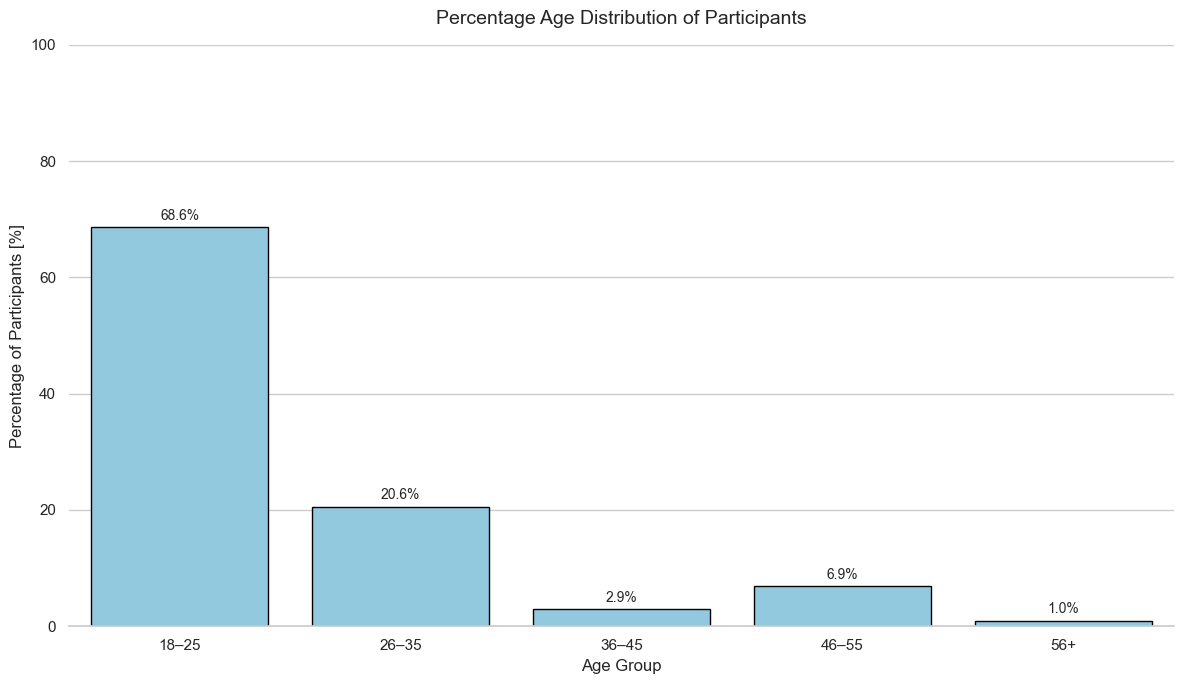

In [5]:
today_year = datetime.today().year
df["birth_date_parsed"] = pd.to_datetime(df["Podaj swoją datę urodzenia"], errors="coerce", dayfirst=True)
df["birth_year"] = df["birth_date_parsed"].dt.year
df["age"] = today_year - df["birth_year"]

bins = [18, 25, 35, 45, 55, 100]
labels = ["18–25", "26–35", "36–45", "46–55", "56+"]
valid_ages = df["age"].dropna()
counts, _ = np.histogram(valid_ages, bins=bins)
percentages = counts / counts.sum() * 100

df_age = pd.DataFrame({"Age Group": labels, "Percentage": percentages})
plot_bar_chart(df_age, x="Age Group", y="Percentage", hue="Age Group", 
               title="Percentage Age Distribution of Participants", 
               xlabel="Age Group", legend=False, palette=["skyblue"]*len(labels))

## Education of the respondents

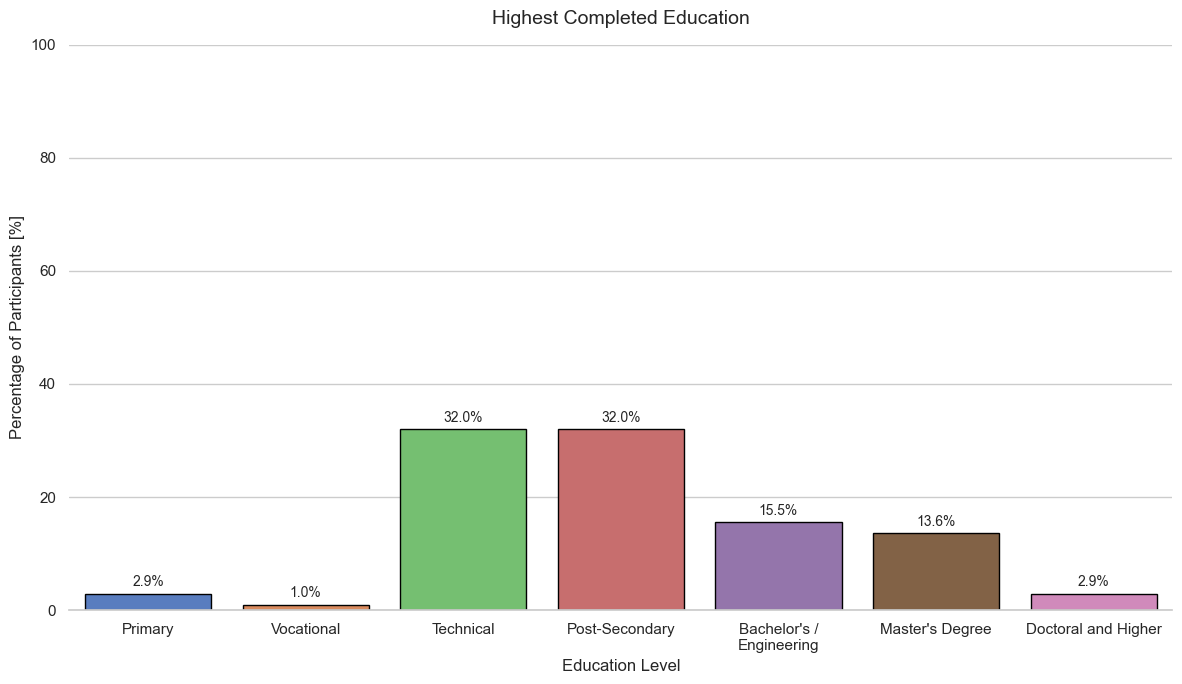

In [6]:
# === Configuration & Data Preparation ===
col_edu = "Jakie jest Twoje najwyższe ukończone wykształcenie?"
col_gender = "Podaj swoją płeć"
col_mask_now = "Czy obecnie zdarza Ci się nosić maseczkę ochronną?"
col_exp = "Czy miałeś/aś doświadczenie z noszeniem maseczki ochronnej (np. w ramach swoich obowiązków lub w czasie pandemii COVID-19 2020–2022)?"
col_context = "W jakim kontekście najczęściej nosiłeś/aś maseczkę?"
# Translation map for Education
edu_mapping = {
    "Podstawowe": "Primary",
    "Zawodowe": "Vocational",
    "Techniczne": "Technical",
    "Policealne": "Post-Secondary",
    "Wyższe licencjackie/inżynierskie": "Bachelor's / Engineering",
    "Wyższe magisterskie": "Master's Degree",
    "Doktoranckie i wyższe": "Doctoral and Higher"
}
edu_order = [
    "Primary", 
    "Vocational", 
    "Technical", 
    "Post-Secondary", 
    "Bachelor's / Engineering", 
    "Master's Degree", 
    "Doctoral and Higher"
]
df[col_edu] = df[col_edu].replace(edu_mapping)
# Translation map for Gender
gender_mapping = {"Kobieta": "Female", "Mężczyzna": "Male", "Wolę nie podawać": "Other"}
df[col_gender] = df[col_gender].replace(gender_mapping)
# Translation map for mask now and experience with mask
for col in [col_mask_now, col_exp]:
    df[col] = df[col].apply(lambda x: "Yes" if "Tak" in str(x) else "No")
# Translation for cotext
context_mapping = {
    "In public spaces": 0,
    "In hospitals": 0,
    "At home": 0,
    "At work / school": 0,
    "Other": 0
}
for wiersz in df[col_context].dropna():
    wiersz_str = str(wiersz)
    temp = False
    if re.search(r"publicznej",wiersz_str):
        temp = True
        context_mapping["In public spaces"] += 1
    if re.search(r"szpitalach",wiersz_str):
        temp = True
        context_mapping["In hospitals"] += 1
    if re.search(r"domu",wiersz_str):
        temp = True
        context_mapping["At home"] += 1
    if re.search(r"pracy",wiersz_str):
        temp = True
        context_mapping["At work / school"] += 1
    if not temp:
        context_mapping["Other"] += 1
df_plot_context = pd.DataFrame(list(context_mapping.items()), columns=["Context", "Percentage"])
df_plot_context["Percentage"] = (df_plot_context["Percentage"] / 103) * 100
df_plot_context["Context"] = wrap_labels(df_plot_context["Context"], width=20)
df_plot_context = df_plot_context.sort_values(by="Percentage", ascending=False)
# === Executing Plots ===
plot_single_column(df, col_edu, "Highest Completed Education", "Education Level", category_order=edu_order)

## Gender of respondents

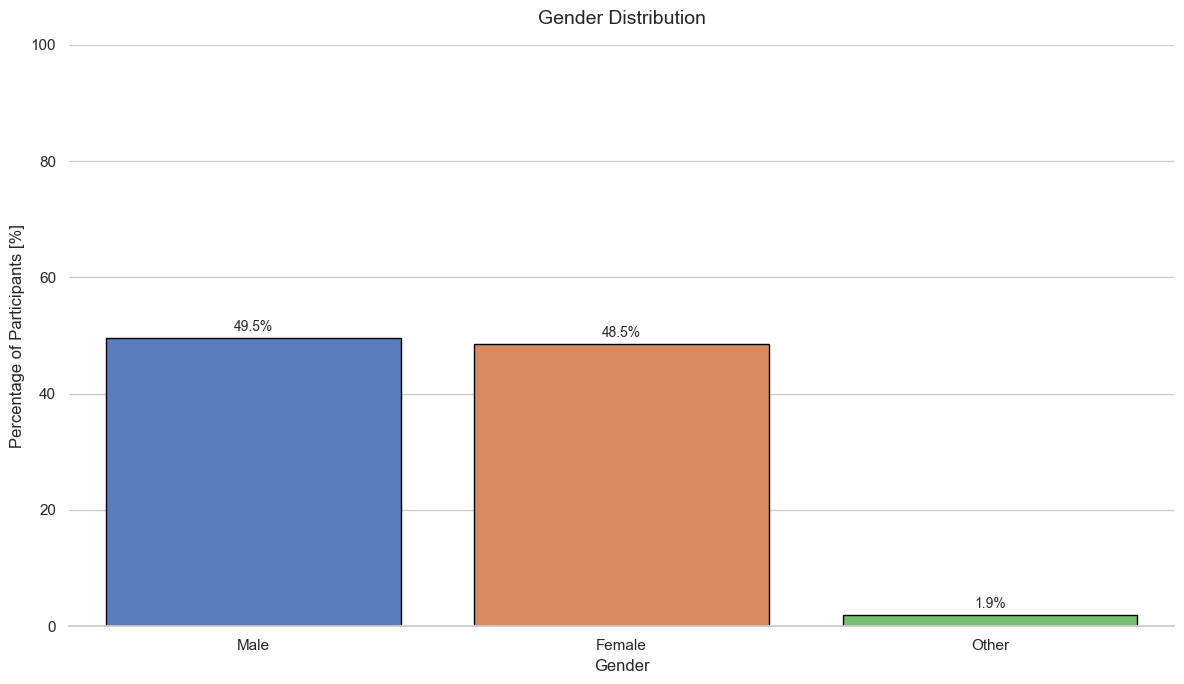

In [7]:
plot_single_column(df, col_gender, "Gender Distribution", "Gender")

## Activity of wearing a mask

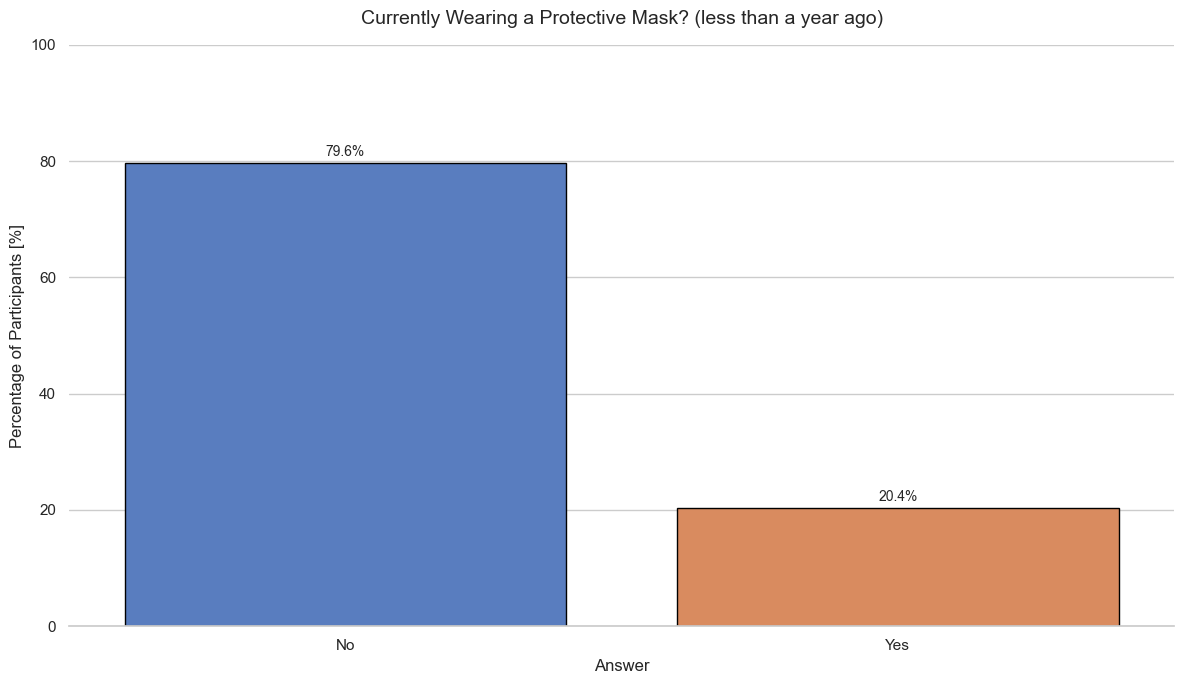

In [8]:
plot_single_column(df, col_mask_now, "Currently Wearing a Protective Mask? (less than a year ago)", "Answer")

## Experience with Wearing Masks
At least once in a lifetime.

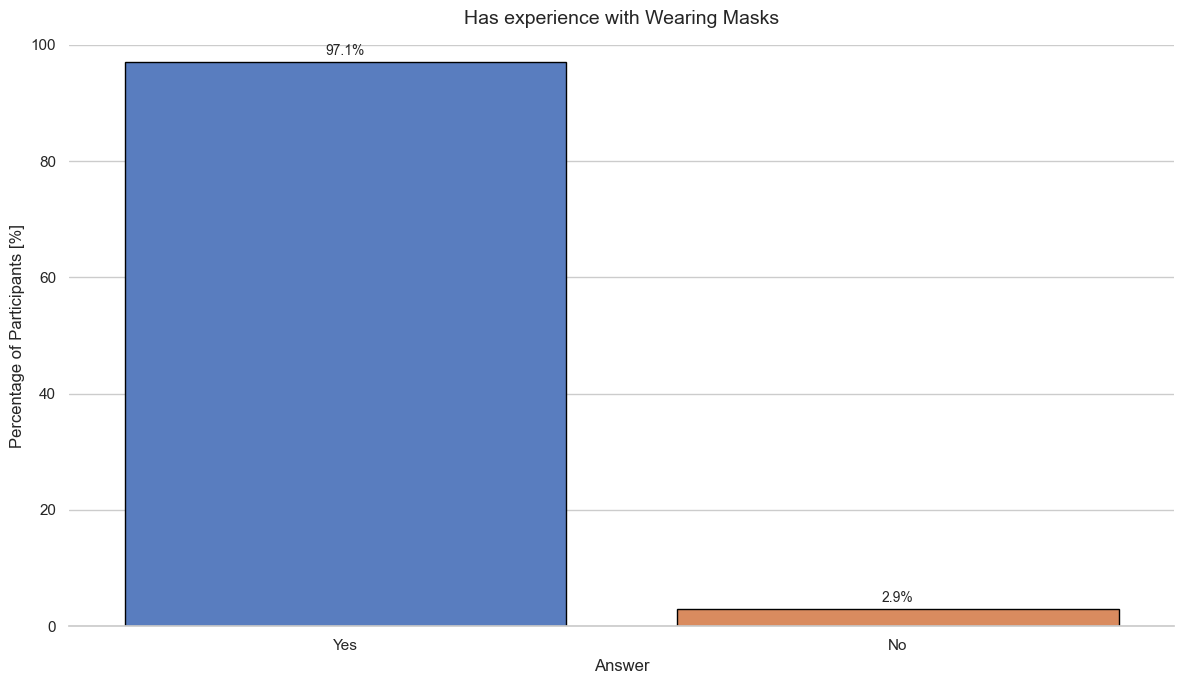

In [9]:
plot_single_column(df, col_exp, "Has experience with Wearing Masks", "Answer", wrap_width=15)

## Where masks were worn

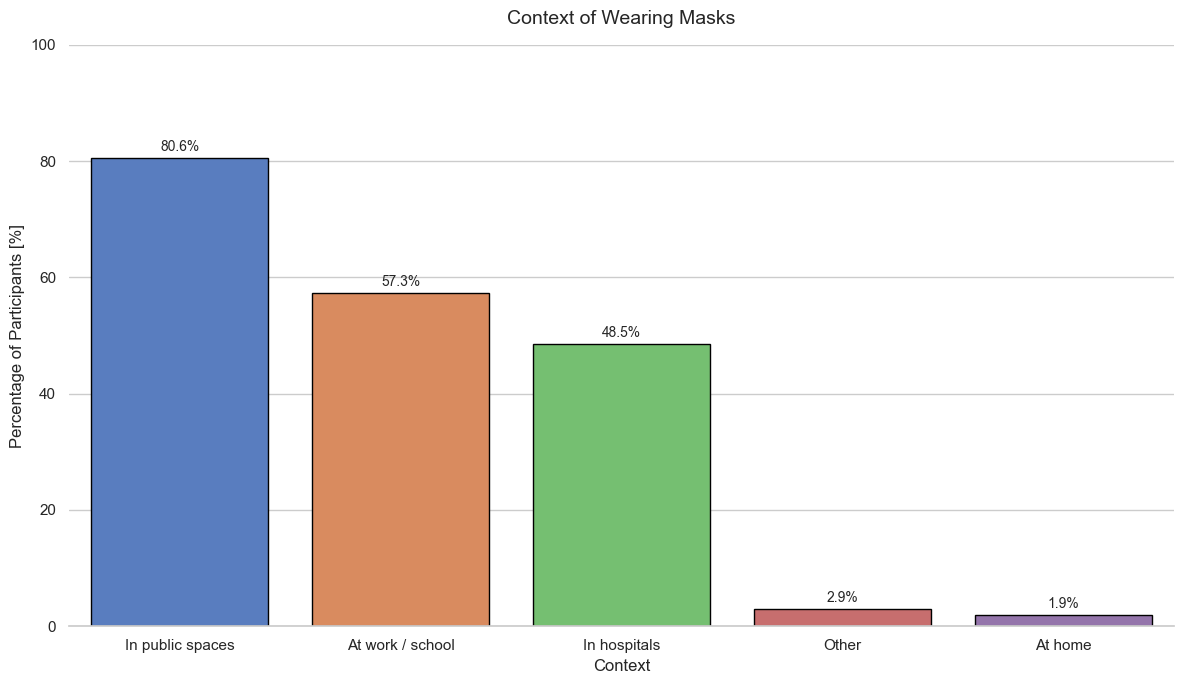

In [10]:
plot_bar_chart(data=df_plot_context, x="Context", y="Percentage", title="Context of Wearing Masks", xlabel="Context",
               hue="Context", legend=False, y_limit=100)

## Is it harder to recognize emotions with a covered face? Before vs. after the survey

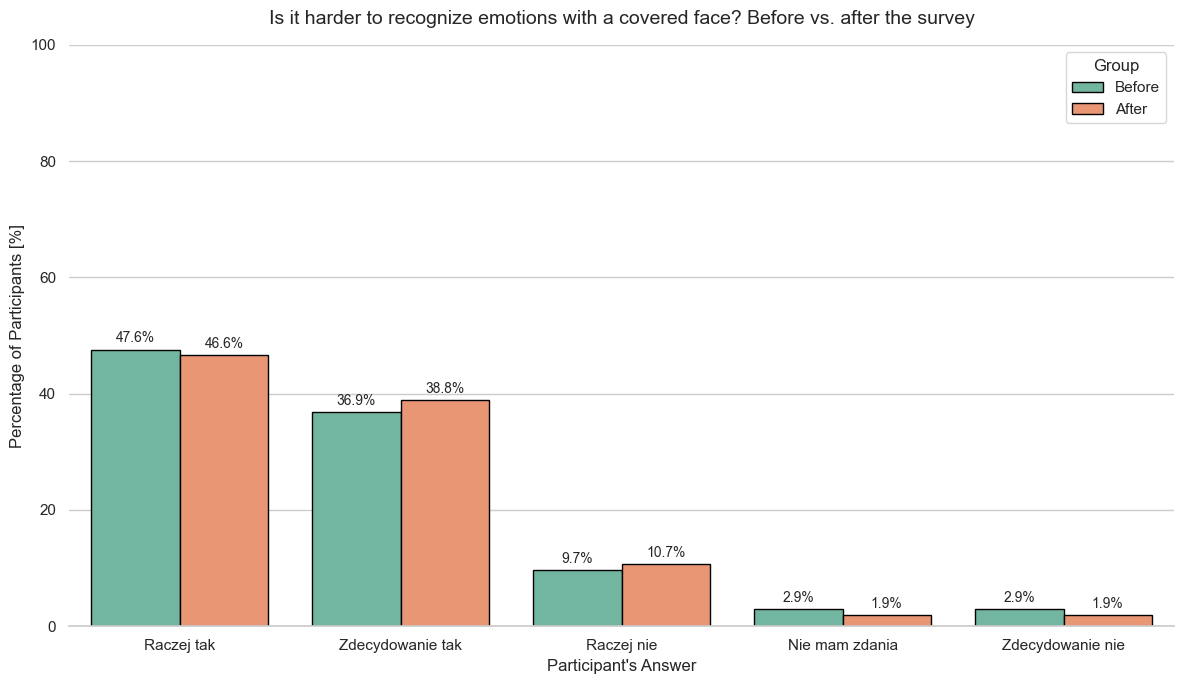

In [11]:
col_rec_before = "1 Czy uważasz, że noszenie maseczki ma wpływ na rozpoznawanie emocji u innych osób?"
col_rec_after = "2 Czy uważasz, że noszenie maseczki utrudnia rozpoznawanie emocji u innych osób?"
counts_before = df[col_rec_before].value_counts(dropna=True, normalize=True) * 100
counts_after = df[col_rec_after].value_counts(dropna=True, normalize=True) * 100
df_comp = pd.DataFrame({"Before": counts_before, "After": counts_after}).fillna(0)
df_comp_reset = df_comp.reset_index().rename(columns={"index": "Answer", col_rec_before: "Answer"})
df_melted_comp = df_comp_reset.melt(id_vars="Answer", var_name="Group", value_name="Percentage")
plot_bar_chart(data=df_melted_comp, x="Answer", y="Percentage", hue="Group", 
    title="Is it harder to recognize emotions with a covered face? Before vs. after the survey", 
    xlabel="Participant's Answer", palette="Set2")

## Feelings of what emotion is difficult to recognize. Before vs. after the survey

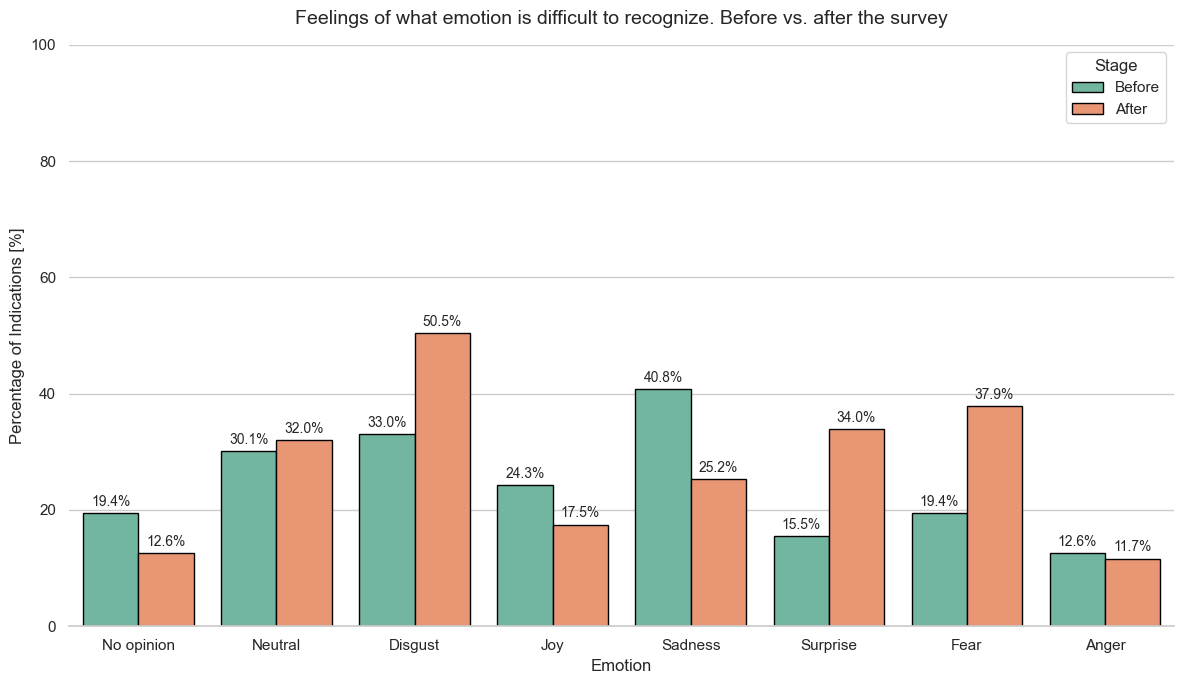

In [12]:
emotions_before = {
    "No opinion": 20, "Neutral": 31, "Disgust": 34, "Joy": 25,
    "Sadness": 42, "Surprise": 16, "Fear": 20, "Anger": 13
}
emotions_after = {
    "No opinion": 13, "Fear": 39, "Surprise": 35, "Disgust": 52,
    "Neutral": 33, "Sadness": 26, "Anger": 12, "Joy": 18
}
total_participants = 103
df_compare = pd.DataFrame({"Before": emotions_before, "After": emotions_after})
df_compare = (df_compare / total_participants) * 100
df_compare_reset = df_compare.reset_index().rename(columns={"index": "Emotion"})
df_melted = df_compare_reset.melt(id_vars="Emotion", var_name="Stage", value_name="Percentage")
plot_bar_chart(df_melted, x="Emotion", y="Percentage", hue="Stage", 
               title="Feelings of what emotion is difficult to recognize. Before vs. after the survey", 
               xlabel="Emotion", ylabel="Percentage of Indications [%]", palette="Set2")

## Correctness calculation & histogram

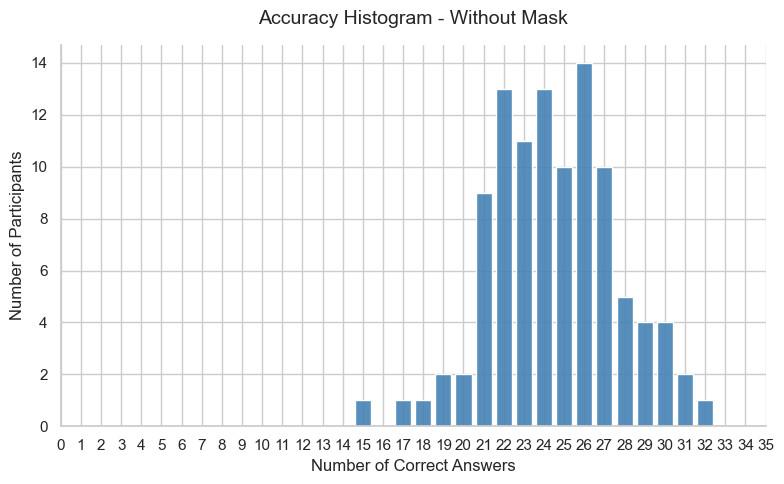

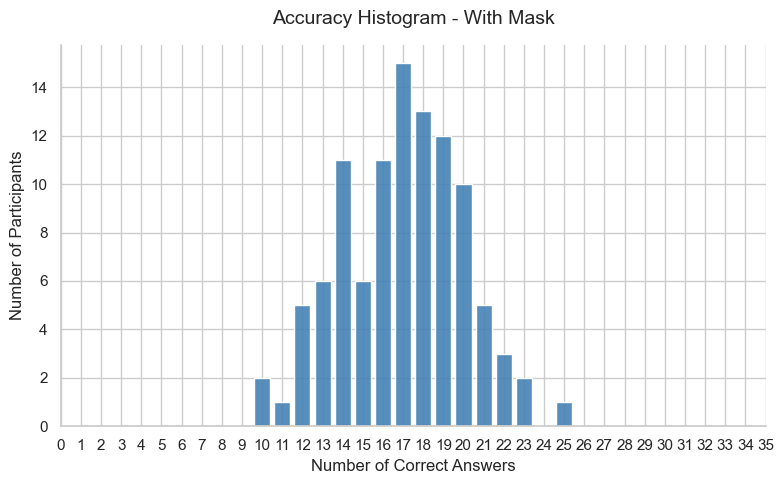

In [13]:
ans_cols = [c for c in df.columns if "_maska_" in c or "_bezmaski_" in c]
true_emotions = {col: get_true_emotion_from_col(col) for col in ans_cols}
accuracy_df = pd.DataFrame()
for col in ans_cols:
    true_emo = true_emotions[col]
    mapped_answers = df[col].apply(normalize_emotion)
    accuracy_df[col] = (mapped_answers == true_emo).astype(int)
cols_mask = [c for c in accuracy_df.columns if "_maska_" in c]
cols_no_mask = [c for c in accuracy_df.columns if "_bezmaski_" in c]
scores_mask = accuracy_df[cols_mask].sum(axis=1)
scores_no_mask = accuracy_df[cols_no_mask].sum(axis=1)
plot_accuracy_histogram(scores_no_mask, "Accuracy Histogram - Without Mask")
plot_accuracy_histogram(scores_mask, "Accuracy Histogram - With Mask")

## Average accuracy per emotion

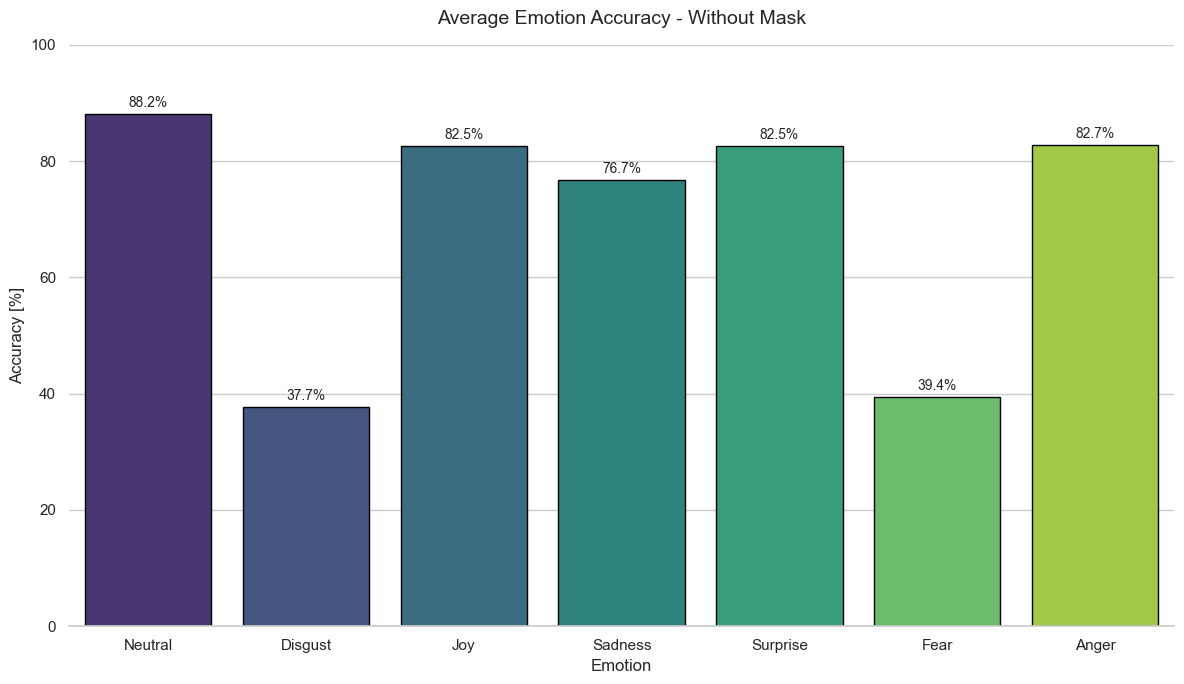

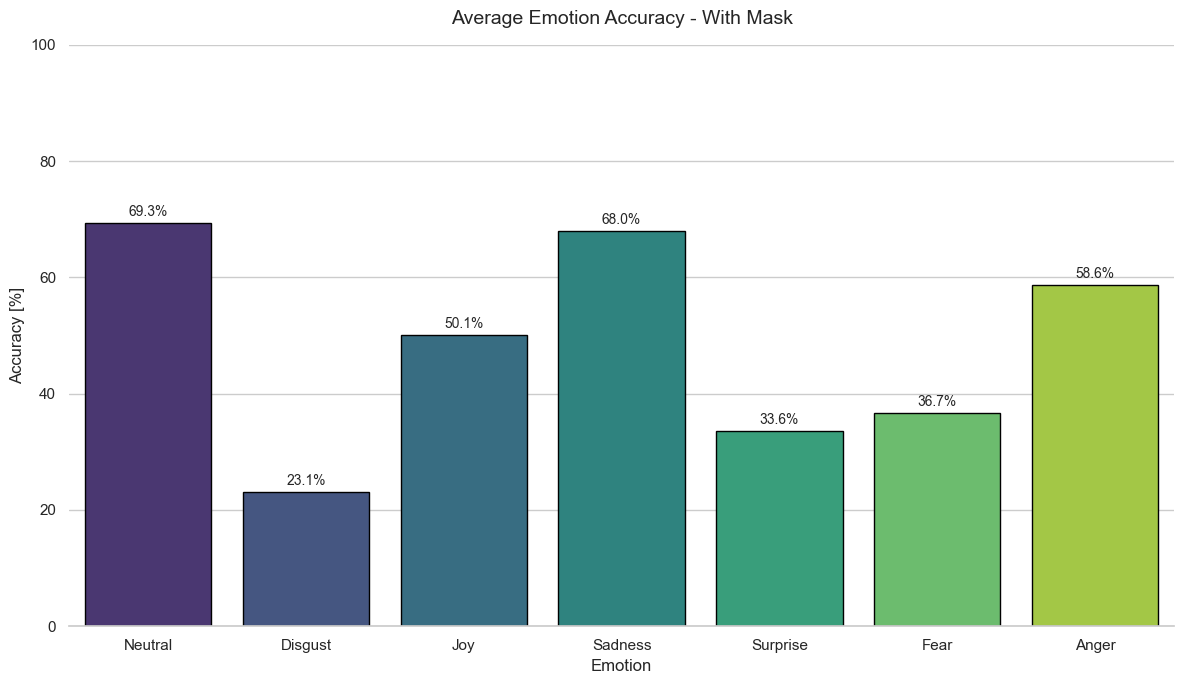

In [14]:
df["percent_correct"] = accuracy_df.mean(axis=1) * 100
unique_emotions = sorted(set(true_emotions.values()))
acc_em_mask, acc_em_no_mask = {}, {}
for emotion in unique_emotions:
    cols_em = [k for k, v in true_emotions.items() if v == emotion]
    c_mask = [k for k in cols_em if "_maska_" in k]
    c_no_mask = [k for k in cols_em if "_bezmaski_" in k]
    acc_em_mask[emotion] = accuracy_df[c_mask].mean().mean() * 100 if c_mask else None
    acc_em_no_mask[emotion] = accuracy_df[c_no_mask].mean().mean() * 100 if c_no_mask else None
ser_acc_mask = pd.Series(acc_em_mask).dropna().sort_values(ascending=False)
ser_acc_no_mask = pd.Series(acc_em_no_mask).dropna().sort_values(ascending=False)
plot_emotion_accuracy(ser_acc_no_mask, "Average Emotion Accuracy - Without Mask")
plot_emotion_accuracy(ser_acc_mask, "Average Emotion Accuracy - With Mask")

## Confusion matrices

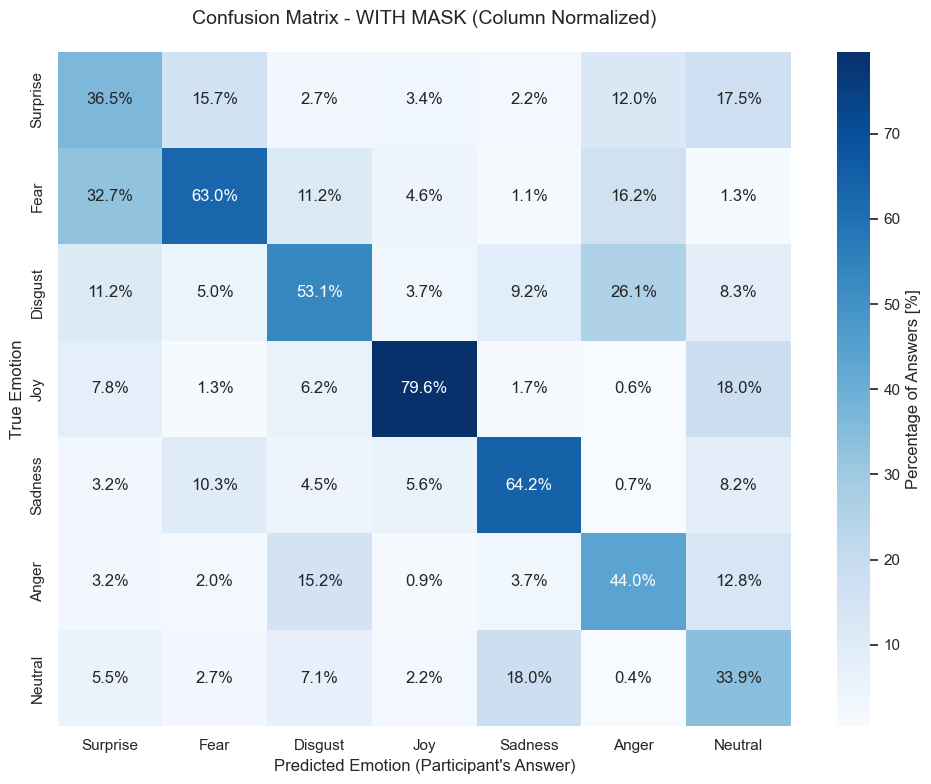

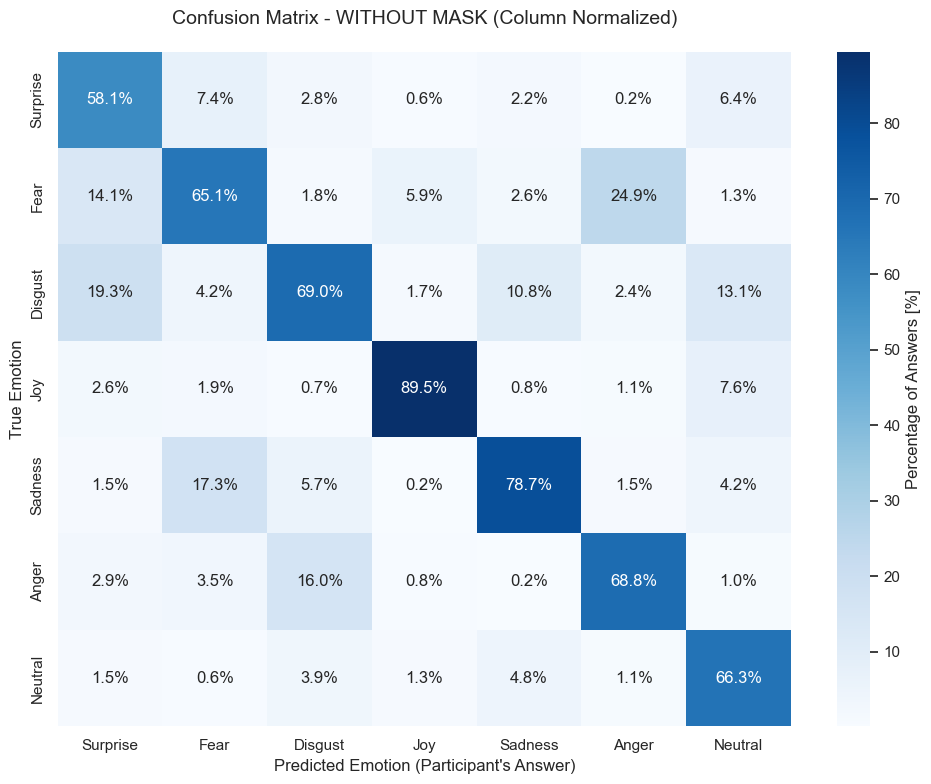

In [15]:
true_mask_list = [get_true_emotion_from_col(c) for c in cols_mask]
true_no_mask_list = [get_true_emotion_from_col(c) for c in cols_no_mask]
cm_mask, ytrue_mask, ypred_mask = generate_confusion_matrix(df, cols_mask, true_mask_list)
cm_no_mask, ytrue_no_mask, ypred_no_mask = generate_confusion_matrix(df, cols_no_mask, true_no_mask_list)
plot_percentage_confusion_matrix(cm_mask, "Confusion Matrix - WITH MASK (Column Normalized)")
plot_percentage_confusion_matrix(cm_no_mask, "Confusion Matrix - WITHOUT MASK (Column Normalized)")

## Metrics

In [16]:
metrics_data = [
    calculate_metrics(ytrue_mask, ypred_mask, EMOTIONS_7, "WITH MASK"),
    calculate_metrics(ytrue_no_mask, ypred_no_mask, EMOTIONS_7, "WITHOUT MASK")
]
df_metrics = pd.DataFrame(metrics_data)
print("\t\t\t\t\tMETRICS FOR HUMAN DETECTION SKILLS\n")
print(df_metrics.to_string(index=False, float_format="{:.4f}".format))

					METRICS FOR HUMAN DETECTION SKILLS

   Condition  Micro Accuracy  Macro Accuracy  Precision (Macro)  Recall (Macro)  F1-score (Macro)  ROC AUC (Macro)
   WITH MASK          0.4849          0.4849             0.5349          0.4849            0.4814           0.6995
WITHOUT MASK          0.6996          0.6996             0.7079          0.6996            0.6863           0.8248
